# Spotify Top-10,000 Songs: Dataset Tour & Quickstart
### A Multimodal Dataset for Hit Song Prediction, Audio Embedding Benchmarks, and Music Recommendation

Welcome! This notebook provides a fast, comprehensive walkthrough of the **Spotify Top-10,000 Songs Dataset**.
We demonstrate how to load and query each component:

1. **Core Metadata & Metrics** (`metadata/songs.parquet`)
2. **Engineered Feature Tables** (`features/audio/`, `features/lyric/`, `features/metadata/`)
3. **Full-Song Deep Audio Embeddings** (`embeddings/audio/` — CLAP, MERT-330M, PANNs, VGGish, Mel Stats)
4. **Multilingual Lyric Embeddings** (`embeddings/lyric/` — Harrier-OSS-v1-0.6B, Multilingual E5-Large)
5. **Instant Pre-computed Top-250 Similarity Graphs** (`similarity/knn_*_top250.parquet` — Audio, Lyric, Mood, Combined)
6. **4-Facet 2D Latent Space Visualizations** (`similarity/umap_2d_*.parquet`)
7. **Zero-Leakage ML Evaluation Splits** (`splits/`)


## 1. Setup & Environment
Run this cell to set up paths. Works seamlessly both on Kaggle and in local clone environments.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from difflib import SequenceMatcher

# Robust path resolution
if Path('data/metadata/songs.parquet').exists():
    DATA_DIR = Path('data')
elif Path('../data/metadata/songs.parquet').exists():
    DATA_DIR = Path('../data')
elif Path('/kaggle/input/spotify-10k-music-features').exists():
    DATA_DIR = Path('/kaggle/input/spotify-10k-music-features')
else:
    raise FileNotFoundError("Dataset path not found. Please ensure data directory exists.")

print(f"Data root resolved to: {DATA_DIR.resolve()}")


Data root resolved to: /home/esstee/projects/top10k/music-prediction/data


## 2. Core Metadata & Engineered Feature Tables
- `metadata/songs.parquet`: 10,000 tracks with Spotify audio features, artist genres, release dates, and lyrics.
- `features/audio/dsp_librosa.parquet`: 91 DSP features (LUFS, onset strength, spectral contrast, MFCCs).
- `features/audio/vad.parquet`: Voice Activity Detection (vocal ratio & duration).
- `features/lyric/go_emotions.parquet`: 28 fine-grained emotional probabilities.
- `features/lyric/lyric_stats.parquet`: Lexical diversity (TTR, hapax ratio, reading ease, VADER & NRC sentiment).
- `features/metadata/derived.parquet`: Temporal decade one-hots, artist collaboration flags, and follower metrics.


In [2]:
songs = pd.read_parquet(DATA_DIR / 'metadata' / 'songs.parquet')
derived = pd.read_parquet(DATA_DIR / 'features' / 'metadata' / 'derived.parquet')
vad = pd.read_parquet(DATA_DIR / 'features' / 'audio' / 'vad.parquet')

print(f"Loaded {len(songs):,} songs across {len(songs.columns)} columns.")
display(songs[['rank', 'track_name', 'artist_names', 'popularity', 'danceability', 'energy', 'valence', 'main_genres']].head(7))


Loaded 10,000 songs across 32 columns.


,rank,track_name,artist_names,popularity,danceability,energy,valence,main_genres
0,1,Die With A Smile,Lady Gaga|Bruno Mars,100,0.521,0.59200,0.535,"Electronic, Pop"
1,2,DtMF,Bad Bunny,98,0.625,0.13100,0.032,"Hip Hop, Latin"
2,3,BIRDS OF A FEATHER,Billie Eilish,98,0.747,0.50700,0.438,Pop
3,4,Clean Baby Sleep White Noise (Loopable),Dream Supplier|Baby Sleeps|Background White Noise,97,NaN,NaN,NaN,"Easy Listening, Electronic, New Age, Tradition..."
4,5,BAILE INoLVIDABLE,Bad Bunny,96,0.168,0.00332,0.219,"Hip Hop, Latin"
5,6,Not Like Us,Kendrick Lamar,96,0.898,0.47200,0.214,Hip Hop
6,7,That’s So True,Gracie Abrams,96,0.554,0.80800,0.372,Pop


Search songs by title, artist.

In [3]:
def get_cleaning_score(query: str, target: str) -> float:
    """Calculate a match ratio between 0 and 1."""
    if not query:
        return 1.0

    if pd.isna(target):
        return 0.0

    query = str(query).lower().strip()
    target = str(target).lower().strip()

    # Exact / substring match
    if query in target:
        return 0.5 + (0.5 * len(query) / len(target))

    # Fuzzy match
    return SequenceMatcher(None, query, target).ratio()


def search_songs(
    title: str,
    artist: str,
    songs_df: pd.DataFrame,
    max_result_count: int = 10,
    min_score: float = 0.1,
    ) -> pd.DataFrame:
    """
    Search songs by title and/or artist.

    Returns only:
        track_id
        relevance_score
    """

    if not title and not artist:
        return pd.DataFrame({
            "track_id": songs_df["track_id"].head(max_result_count),
            "relevance_score": 1.0,
        })

    title_scores = None
    artist_scores = None

    if title:
        title_scores = songs_df["track_name"].apply(
            lambda x: get_cleaning_score(title, x)
        )

    if artist:
        artist_scores = songs_df["artist_names"].apply(
            lambda x: get_cleaning_score(artist, x)
        )

    if title and artist:
        relevance_score = title_scores * artist_scores
    elif title:
        relevance_score = title_scores
    else:
        relevance_score = artist_scores

    results = pd.DataFrame({
        "track_id": songs_df["track_id"],
        "relevance_score": relevance_score,
    })

    return (
        results[results["relevance_score"] > min_score]
        .sort_values("relevance_score", ascending=False)
        .head(max_result_count)
        .reset_index(drop=True)
    )
    
# Search
matches = search_songs(
    "Billie Jean",
    "Michael Jackson",
    songs, 5
)

# Decide what metadata you want
wanted_columns = [
    "rank",
    "track_id",
    "track_name",
    "artist_names",
    "album_name",
    "popularity",
]

# Retrieve metadata + attach score
result = (
    matches
    .merge(songs[wanted_columns], on="track_id", how="left")
    [wanted_columns + ["relevance_score"]]
)

print(result.to_string(index=False))

 rank               track_id                     track_name    artist_names   album_name  popularity  relevance_score
  654 7J1uxwnxfQLu4APicE5Rnj                    Billie Jean Michael Jackson     Thriller          83         1.000000
 6393 2LlQb7Uoj1kKyGhlkBf9aC                       Thriller Michael Jackson     Thriller          73         0.421053
 1533 3BovdzfaX4jb5KFQwoPfAw                        Beat It Michael Jackson     Thriller          80         0.333333
 1921 46eu3SBuFCXWsPT39Yg3tJ Don't Stop 'Til You Get Enough Michael Jackson Off the Wall          79         0.292683
 1535 7oOOI85fVQvVnK5ynNMdW7 Rock with You - Single Version Michael Jackson Off the Wall          80         0.292683


## 3. Full-Song Acoustic Embeddings (`embeddings/audio/`)
All audio representations were extracted over **100% full-song audio durations**:
- `clap_512d.npy`: LAION-CLAP zero-shot acoustic-text contrastive embeddings (512-D).
- `mert_330m_embeddings_1024d.npy`: Mean-pooled MERT-v1-330M musical transformer embeddings (1024-D).
- `panns_embeddings_2048d.npy`: PANNs CNN14 audio pattern embeddings (2048-D).
- `vggish_embeddings_128d.npy`: Google VGGish acoustic texture embeddings (128-D).
- `mel_stats_embeddings_512d.npy`: Spectral distribution statistics (512-D).


In [4]:
clap = np.load(DATA_DIR / 'embeddings' / 'audio' / 'clap_512d.npy')
mert = np.load(DATA_DIR / 'embeddings' / 'audio' / 'mert_330m_embeddings_1024d.npy')
vgg  = np.load(DATA_DIR / 'embeddings' / 'audio' / 'vggish_embeddings_128d.npy')

print("Main audio embeddings loaded:")
print(f"CLAP Embedding shape:     {clap.shape}")
print(f"MERT-330M shape:          {mert.shape}")
print(f"VGGish shape:             {vgg.shape}")
print()

panns = np.load(DATA_DIR / 'embeddings' / 'audio' / 'panns_embeddings_2048d.npy')
melstats = np.load(DATA_DIR / 'embeddings' / 'audio' / 'mel_stats_embeddings_512d.npy')
pannstags = np.load(DATA_DIR / 'embeddings' / 'audio' / 'panns_tags_527d.npy')


print("Other audio embeddings loaded:")
print(f"PANNS Embedding shape:    {panns.shape}")
print(f"MelStats Embedding shape: {melstats.shape}")
print(f"PANNS Tags shape:         {pannstags.shape}")


Main audio embeddings loaded:
CLAP Embedding shape:     (10000, 512)
MERT-330M shape:          (10000, 1024)
VGGish shape:             (10000, 128)

Other audio embeddings loaded:
PANNS Embedding shape:    (10000, 2048)
MelStats Embedding shape: (10000, 512)
PANNS Tags shape:         (10000, 527)


## 4. Multilingual Lyric Representations (`embeddings/lyric/`)
- `harrier_embeddings_1024d.npy`: Microsoft Harrier-OSS-v1-0.6B state-of-the-art multilingual embedding model (1024-D).
- `multilingual_e5_large_1024d.npy`: Multilingual E5-Large sentence embeddings (1024-D).
- `bge_m3_1024d.npy`: BGE-M3 multilingual embeddings (1024-D).
- `features/lyric/language_id.parquet`: Primary/secondary language classification across 26 languages.


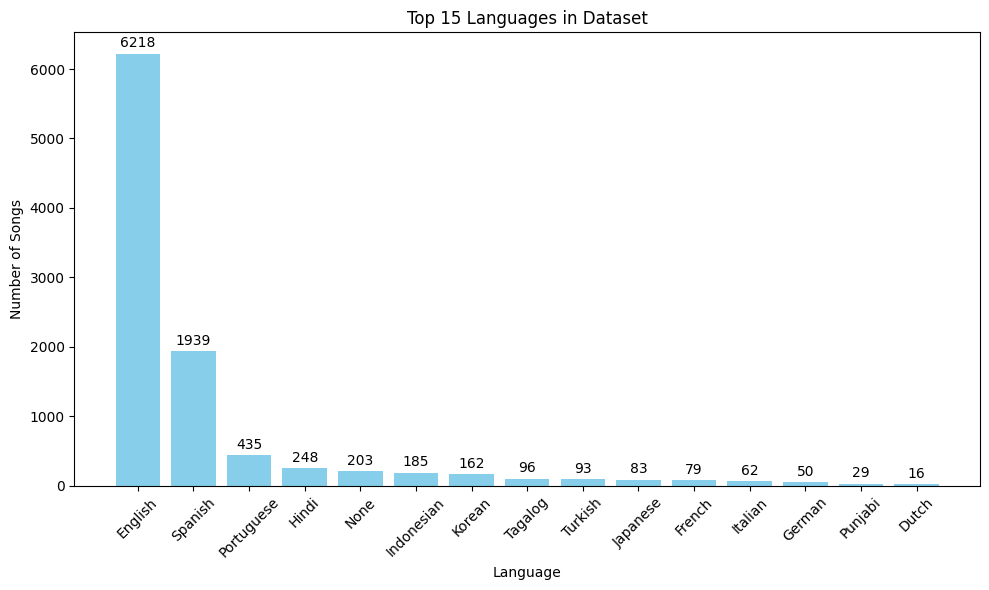

In [5]:
# Normalize romanized Hindi into the standard Hindi code before mapping labels

language_file = DATA_DIR / 'features' / 'lyric' / 'language_id.parquet'

language_dict = {
    'en': 'English',
    'es': 'Spanish',
    'pt': 'Portuguese',
    'id': 'Indonesian',
    'hi': 'Hindi',
    'ko': 'Korean',
    'tl': 'Tagalog',
    'tr': 'Turkish',
    'ja': 'Japanese',
    'fr': 'French',
    'it': 'Italian',
    'de': 'German',
    'pa': 'Punjabi',
    'nl': 'Dutch',
    'none': 'None'
}

# Read parquet and define lang_id
lang_id = pd.read_parquet(language_file)[['track_id', 'primary_language']].copy()
lang_id['primary_language'] = lang_id['primary_language'].astype(str).str.strip()

# Normalize common variants
lang_id['primary_language'] = lang_id['primary_language'].replace({
    'hi_romanized': 'hi',
    'romanized_hi': 'hi',
    'hindi_romanized': 'hi',
    'und': 'none',
    'unknown': 'none'
})

# Map to readable names and count
top_languages = (
    lang_id['primary_language']
    .map(lambda x: language_dict.get(x, x))
    .value_counts()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 6))
plt.bar(top_languages.index, top_languages.values, color='skyblue')
plt.title('Top 15 Languages in Dataset')
plt.xlabel('Language')
plt.ylabel('Number of Songs')
plt.xticks(rotation=45)

for i, v in enumerate(top_languages.values):
    plt.text(i, v + 50, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


## 5. Instant Similarity Search with Pre-computed Top-250 kNN Graphs (`similarity/`)
We load the pre-computed Top-250 similarity matrices for sub-millisecond query lookups:
- `knn_audio_top250.parquet`: Fused acoustic similarity (`CLAP + MERT-330M + VGGish` = 1664-D).
- `knn_lyric_top250.parquet`: Fused lyrical storytelling similarity (`Harrier + E5-Large` = 2048-D).
- `knn_mood_top250.parquet`: Unified mood, vibe & context similarity (`Genre 40% + Spotify 30% + Temporal 15% + Vocal 15%` = 83-D).
- `knn_combined_top250.parquet`: Master multimodal similarity (`73% Neural (Audio 38% + Lyric 35%) + 27% Context (Genre 11% + Spotify 8% + Temporal 4% + Vocal 4%)` = 3795-D).


In [6]:
# Load all 4 similarity graphs
knn_audio = pd.read_parquet(DATA_DIR / 'similarity' / 'knn_audio_top250.parquet')
knn_lyric = pd.read_parquet(DATA_DIR / 'similarity' / 'knn_lyric_top250.parquet')
knn_mood  = pd.read_parquet(DATA_DIR / 'similarity' / 'knn_mood_top250.parquet')
knn_comb  = pd.read_parquet(DATA_DIR / 'similarity' / 'knn_combined_top250.parquet')

query_idx = 653
query_title = songs.iloc[query_idx]['track_name']
query_artist = songs.iloc[query_idx]['artist_names']

print(f"Target Song [{query_idx}]: '{query_title}' by {query_artist}\n")

print("1. Acoustically Most Similar (knn_audio_top250):")
for nb_idx, sim in zip(knn_audio.iloc[query_idx]['top250_neighbor_indices'][:5], knn_audio.iloc[query_idx]['top250_similarities'][:5]):
    print(f"  - '{songs.iloc[nb_idx]['track_name']}' by {songs.iloc[nb_idx]['artist_names']} (Sim: {sim:.3f})")

print("\n2. Lyrically Most Similar (knn_lyric_top250):")
for nb_idx, sim in zip(knn_lyric.iloc[query_idx]['top250_neighbor_indices'][:5], knn_lyric.iloc[query_idx]['top250_similarities'][:5]):
    print(f"  - '{songs.iloc[nb_idx]['track_name']}' by {songs.iloc[nb_idx]['artist_names']} (Sim: {sim:.3f})")

print("\n3. Mood & Vibe Most Similar (knn_mood_top250):")
for nb_idx, sim in zip(knn_mood.iloc[query_idx]['top250_neighbor_indices'][:5], knn_mood.iloc[query_idx]['top250_similarities'][:5]):
    print(f"  - '{songs.iloc[nb_idx]['track_name']}' by {songs.iloc[nb_idx]['artist_names']} (Sim: {sim:.3f})")

print("\n4. Master Multimodal Recommendations (knn_combined_top250):")
for nb_idx, sim in zip(knn_comb.iloc[query_idx]['top250_neighbor_indices'][:5], knn_comb.iloc[query_idx]['top250_similarities'][:5]):
    print(f"  - '{songs.iloc[nb_idx]['track_name']}' by {songs.iloc[nb_idx]['artist_names']} (Sim: {sim:.3f})")


Target Song [653]: 'Billie Jean' by Michael Jackson

1. Acoustically Most Similar (knn_audio_top250):
  - 'P.Y.T. (Pretty Young Thing)' by Michael Jackson (Sim: 0.953)
  - 'Night Fever - From "Saturday Night Fever" Soundtrack' by Bee Gees (Sim: 0.948)
  - 'Don't Stop 'Til You Get Enough' by Michael Jackson (Sim: 0.944)
  - 'Blame It on the Boogie' by The Jacksons (Sim: 0.943)
  - 'Let's Groove' by Earth, Wind & Fire (Sim: 0.941)

2. Lyrically Most Similar (knn_lyric_top250):
  - 'Shut Up and Dance' by WALK THE MOON (Sim: 0.815)
  - 'Baby' by Justin Bieber|Ludacris (Sim: 0.811)
  - 'Forever' by Chris Brown (Sim: 0.811)
  - 'Spin You Around' by Morgan Wallen (Sim: 0.810)
  - 'Steal My Girl' by One Direction (Sim: 0.807)

3. Mood & Vibe Most Similar (knn_mood_top250):
  - 'P.Y.T. (Pretty Young Thing)' by Michael Jackson (Sim: 0.995)
  - 'Beat It' by Michael Jackson (Sim: 0.987)
  - 'Use Me' by Bill Withers (Sim: 0.976)
  - 'Remember the Time' by Michael Jackson (Sim: 0.974)
  - 'They Don'

## 6. Multi-Modal 2D Visualizations (`similarity/umap_2d_*.parquet`)
Side-by-side 2D semantic maps comparing **Acoustic Audio Space**, **Semantic Lyric Space**, **Unified Mood & Context Space (83-D)**, and **Master Multimodal Space (3,795-D)**.

> **Interpretation Note**: The 2D coordinates in `similarity/umap_2d_*.parquet` are qualitative non-linear dimensionality reduction projections intended for visual exploration and clustering inspection. For quantitative metric distance or true mathematical similarity, always use the high-dimensional embeddings or the Top-250 kNN graph tables.


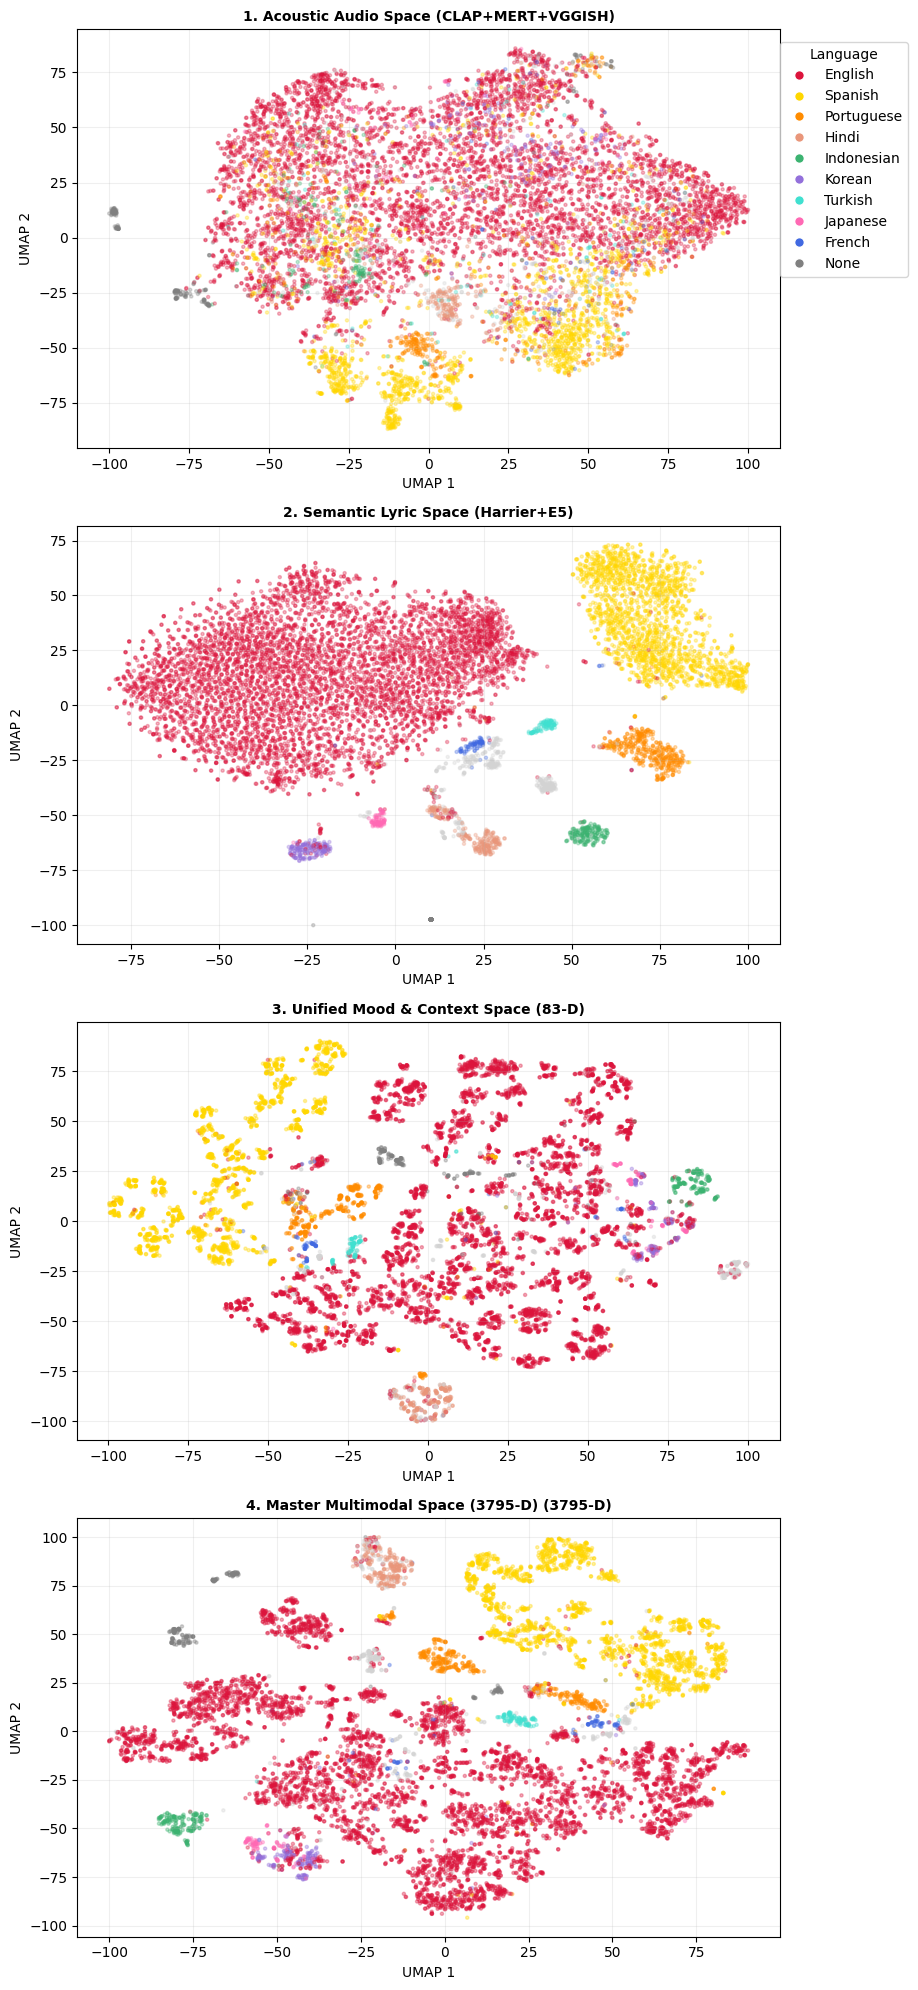

In [7]:
# Load all 4 UMAP projections
umap_audio = pd.read_parquet(DATA_DIR / 'similarity' / 'umap_2d_audio.parquet')
umap_lyric = pd.read_parquet(DATA_DIR / 'similarity' / 'umap_2d_lyric.parquet')
umap_mood  = pd.read_parquet(DATA_DIR / 'similarity' / 'umap_2d_mood.parquet')
umap_comb  = pd.read_parquet(DATA_DIR / 'similarity' / 'umap_2d_combined.parquet')


# Color mappings
lang_color_map = {
    'en': 'crimson', 'es': 'gold', 'pt': 'darkorange', 'hi': 'darksalmon',
    'id': 'mediumseagreen', 'ko': 'mediumpurple', 'tr': 'turquoise', 'ja': 'hotpink',
    'fr': 'royalblue', 'none': 'gray'
}
lang_colors = lang_id['primary_language'].map(lang_color_map).fillna('lightgray')


genre_color_map = {
    'pop': 'dodgerblue', 'rap': 'crimson', 'hip hop': 'darkred',
    'rock': 'darkorange', 'latin': 'gold', 'dance pop': 'deepskyblue', 'edm': 'mediumpurple'
}
audio_colors = songs['main_genres'].map(lambda g: genre_color_map.get(g, 'lightgray'))


fig, axes = plt.subplots(4, 1, figsize=(8, 20))


# 1. Audio UMAP
axes[0].scatter(umap_audio['proj_x'], umap_audio['proj_y'], c=lang_colors, alpha=0.3, s=5)
axes[0].set_title("1. Acoustic Audio Space (CLAP+MERT+VGGISH)", fontsize=10, fontweight='bold')
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[0].grid(True, alpha=0.2)


# 2. Lyric UMAP
axes[1].scatter(umap_lyric['proj_x'], umap_lyric['proj_y'], c=lang_colors, alpha=0.3, s=5)
axes[1].set_title("2. Semantic Lyric Space (Harrier+E5)", fontsize=10, fontweight='bold')
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].grid(True, alpha=0.2)


# 3. Mood UMAP
axes[2].scatter(umap_mood['proj_x'], umap_mood['proj_y'], c=lang_colors, alpha=0.35, s=5)
axes[2].set_title("3. Unified Mood & Context Space (83-D)", fontsize=10, fontweight='bold')
axes[2].set_xlabel("UMAP 1")
axes[2].set_ylabel("UMAP 2")
axes[2].grid(True, alpha=0.2)


# 4. Master Combined UMAP
axes[3].scatter(umap_comb['proj_x'], umap_comb['proj_y'], c=lang_colors, alpha=0.35, s=5)
axes[3].set_title("4. Master Multimodal Space (3795-D)", fontsize=10, fontweight='bold')
axes[3].set_xlabel("UMAP 1")
axes[3].set_ylabel("UMAP 2")
axes[3].grid(True, alpha=0.2)


# Single shared legend for language colors
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=language_dict.get(lang, lang),
           markerfacecolor=color, markersize=7)
    for lang, color in lang_color_map.items()
]
fig.legend(handles=legend_elements, title="Language", loc='upper right',
           bbox_to_anchor=(1.15, 0.98), frameon=True)


plt.tight_layout()
plt.show()


## 7. Machine Learning Splits (`splits/`)
- `artist_grouped_5fold.parquet`: GroupKFold by `artist_id` guaranteeing zero artist leakage across train and test folds.
- `temporal_split.parquet`: Chronological train / val / test evaluation.


In [8]:
art_split = pd.read_parquet(DATA_DIR / 'splits' / 'artist_grouped_5fold.parquet')
temp_split = pd.read_parquet(DATA_DIR / 'splits' / 'temporal_split.parquet')

print("Artist Grouped 5-Fold distribution:")
print(art_split['fold'].value_counts().sort_index())

print("\nTemporal Train / Val / Test distribution:")
print(temp_split['split'].value_counts())


Artist Grouped 5-Fold distribution:
fold
0    2000
1    2000
2    2000
3    2000
4    2000
Name: count, dtype: int64

Temporal Train / Val / Test distribution:
split
train    6549
test     2608
val       843
Name: count, dtype: int64
